# Global Solution 2026.1 — Computação Quântica e IA
## Manutenção Preditiva de Infraestrutura Espacial com Quantum Machine Learning

***Integrantes***
- Igor Paixão Sarak 563726
- Lucca Phelipe Masini RM 564121
- Bernardo Braga Perobeli RM 562468

**FIAP · Turma 2TIAP(F-Y)-2026 · Indústria Espacial × Computação Quântica e IA**

Classificação binária **"motor saudável" vs "motor crítico (próximo da falha)"** a partir da
telemetria de sensores do dataset **NASA C-MAPSS** (Turbofan Engine Degradation), comparando um
modelo **Quantum Machine Learning (QSVC e VQC)** com baselines clássicos (SVM-RBF e Random Forest).

> **ODS 9 — Indústria, inovação e infraestrutura.** Manutenção preditiva confiável de motores
> aeroespaciais é infraestrutura crítica da economia espacial: antecipar falhas reduz custos,
> aumenta a segurança de missões e prolonga a vida útil de ativos orbitais e de propulsão.

**Sumário**
0. Setup e reprodutibilidade
1. Introdução e contexto espacial
2. Carga e união dos dados
3. Rotulagem (alvo binário)
4. Análise exploratória (EDA)
5. Split treino/teste sem *data leakage*
6. Pré-processamento (MinMaxScaler [-π, π] → PCA → SMOTE)
7. Subconjunto quântico
8. Implementação QML (QSVC + VQC, Qiskit)
9. Baselines clássicos
10. Benchmarking e métricas
11. Análise e discussão
12. Conclusões, limitações e próximos passos

### ⚙️ Execução no Kaggle com GPU

Este notebook detecta automaticamente o ambiente:
- **No Kaggle**, a célula abaixo instala o stack Qiskit 1.x com **`qiskit-aer-gpu`** e a simulação
  quântica roda na **GPU** (ative *Settings → Accelerator → GPU*).
- **Localmente**, usa as dependências já instaladas e cai para **CPU** automaticamente.

A simulação roda no **Qiskit Aer com `shots=1024`** (conforme o enunciado), de forma reprodutível
(`seed=42`) tanto em GPU quanto em CPU.

In [1]:
import os, sys, subprocess
ON_KAGGLE = os.path.exists("/kaggle")
if ON_KAGGLE:
    pkgs = ["qiskit==1.4.5", "qiskit-machine-learning==0.8.4", "qiskit-aer-gpu",
            "imbalanced-learn==0.14.1", "pylatexenc==2.10"]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
    print("Ambiente Kaggle detectado — dependências (GPU) instaladas.")
else:
    print("Ambiente local — usando dependências já instaladas (CPU).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 k

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


## 0. Setup e reprodutibilidade

Todas as fontes de aleatoriedade são fixadas em `SEED = 42` para garantir que o notebook seja **100% reproduzível** (mesmo resultado a cada execução do zero).

In [2]:
import os, time, sqlite3, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score, roc_curve, confusion_matrix)
from imblearn.over_sampling import SMOTE

from qiskit import transpile
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
algorithm_globals.random_seed = SEED
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Hiperparâmetros globais do experimento
N_QUBITS    = 4     # nº de qubits == nº de componentes do PCA (faixa NISQ 3-5)
RUL_THRESH  = 30    # ciclos: RUL <= 30 => classe "crítico" (1)
N_TRAIN_Q   = 200   # amostras de TREINO do modelo quântico (<= 400, limite do simulador)
N_TEST      = 120   # amostras de TESTE (mesmas para TODOS os modelos -> comparação justa)

# Localiza o banco automaticamente (local OU dataset do Kaggle em /kaggle/input/...)
_cands = ["data-base/cmapss_dataset.sqlite", "cmapss_dataset.sqlite"]
_cands += glob.glob("/kaggle/input/**/cmapss_dataset.sqlite", recursive=True)
DB_PATH = next((p for p in _cands if os.path.exists(p)), _cands[0])

# /kaggle/input/ é read-only: SQLite não consegue criar arquivos de journal
# → copiamos para /kaggle/working/ (gravável) antes de conectar
if ON_KAGGLE and DB_PATH.startswith("/kaggle/input"):
    import shutil as _shutil
    _w = "/kaggle/working/cmapss_dataset.sqlite"
    if not os.path.exists(_w):
        _shutil.copy(DB_PATH, _w)
        print("DB copiado para área gravável:", _w)
    DB_PATH = _w

print("Ambiente pronto. Seed =", SEED, "| N_QUBITS =", N_QUBITS, "| DB:", DB_PATH)

DB copiado para área gravável: /kaggle/working/cmapss_dataset.sqlite
Ambiente pronto. Seed = 42 | N_QUBITS = 4 | DB: /kaggle/working/cmapss_dataset.sqlite


### Detecção de dispositivo (GPU / CPU)

Cria um **`SamplerV2` do Qiskit Aer** (com `shots=1024`) reutilizado pelo **QSVC** e pelo **VQC**, junto de um **pass manager** que transpila os circuitos para o backend. Se houver GPU (`qiskit-aer-gpu`), o `device` é `GPU`; senão, `CPU`. Se o Aer falhar, há *fallback* automático para as *primitives* de referência (statevector exato).

In [3]:
USE_GPU = False
try:
    if "GPU" in AerSimulator().available_devices():
        USE_GPU = True
except Exception as _e:
    print("Aer indisponível:", _e)
DEVICE = "GPU" if USE_GPU else "CPU"
SHOTS  = 1024

try:
    _backend = AerSimulator(device=DEVICE, method="statevector")
    PASS_MANAGER = generate_preset_pass_manager(optimization_level=1, backend=_backend)
    SAMPLER = AerSamplerV2.from_backend(_backend, default_shots=SHOTS, seed=SEED)
    _AER_OK = True
except Exception as _e:
    print("Aer SamplerV2 indisponível, usando primitives de referência:", _e)
    SAMPLER, PASS_MANAGER, _AER_OK = None, None, False

print(f"Dispositivo de simulação quântica: {DEVICE} | "
      f"Aer SamplerV2: {'ativo (shots=%d)' % SHOTS if _AER_OK else 'fallback (referência exata)'}")

Dispositivo de simulação quântica: GPU | Aer SamplerV2: ativo (shots=1024)


## 1. Introdução e contexto espacial

O espaço tornou-se um ecossistema econômico em rápida expansão: satélites monitoram clima,
orientam o agronegócio, previnem desastres e conectam regiões remotas. A confiabilidade da
**propulsão e da infraestrutura** que sustenta missões espaciais e aeronáuticas é crítica — uma
falha não prevista de motor pode comprometer uma missão inteira.

O dataset **NASA C-MAPSS** (*Commercial Modular Aero-Propulsion System Simulation*) contém séries
temporais *run-to-failure* de uma frota de motores turbofan: cada motor opera normalmente, desenvolve
uma falha que cresce com o tempo, até a falha total. São 21 sensores (temperatura, pressão, rotação,
fluxo) + 3 condições operacionais, contaminados com ruído realista de sensor.

**Problema deste trabalho:** dado um *snapshot* de telemetria de um ciclo de operação, classificar se
o motor está **saudável** (longe da falha) ou **crítico** (RUL — *Remaining Useful Life* — baixo).
Essa é a base de qualquer sistema de **manutenção preditiva** (detecção de anomalias em telemetria),
domínio explicitamente sugerido no briefing (*Manutenção espacial*).

## 2. Carga e união dos dados (Entregável 1)

Unimos as **4 tabelas de treino** do C-MAPSS (FD001–FD004). As tabelas `train_*` são *run-to-failure* (vão até a falha), o que permite derivar o RUL diretamente. As tabelas `test_*` param antes da falha e precisariam do vetor `rul_*` — por isso usamos apenas as `train_*` e fazemos nosso **próprio split** treino/teste (Seção 5).

In [4]:
con = sqlite3.connect(DB_PATH)

SENSORS = ["T2","T24","T30","T50","P2","P15","P30","Nf","Nc","epr","Ps30","phi",
           "NRf","NRc","BPR","farB","htBleed","Nf_dmd","PCNfR_dmd","W31","W32"]
OPSET   = ["operational_setting_1","operational_setting_2","operational_setting_3"]

frames = []
for ds in ["fd001","fd002","fd003","fd004"]:
    df = pd.read_sql(f'SELECT * FROM "train_{ds}"', con)
    df = df.drop(columns=[c for c in ["id","simulate-date"] if c in df.columns])
    df["dataset"] = ds.upper()
    frames.append(df)
con.close()

data = pd.concat(frames, ignore_index=True)
print("Shape combinado:", data.shape)
print("Motores por subdataset:")
print(data.groupby("dataset")["unit_number"].nunique())
data.head()

Shape combinado: (160359, 27)
Motores por subdataset:
dataset
FD001    100
FD002    260
FD003    100
FD004    249
Name: unit_number, dtype: int64


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,T2,T24,T30,T50,P2,...,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392.0,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392.0,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390.0,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392.0,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393.0,2388,100.0,38.90,23.4044,FD001


### Dicionário de dados

| Variável | Descrição | Unidade (aprox.) |
|---|---|---|
| `unit_number` | Identificador do motor (frota) | — |
| `time_in_cycles` | Ciclo de operação (voo) | ciclos |
| `operational_setting_1..3` | Condições operacionais (altitude, Mach, TRA) | normalizado |
| `T2` | Temperatura na entrada do fan | °R |
| `T24` | Temperatura na saída do LPC | °R |
| `T30` | Temperatura na saída do HPC | °R |
| `T50` | Temperatura na saída do LPT | °R |
| `P2` | Pressão na entrada do fan | psia |
| `P15` | Pressão no duto de *bypass* | psia |
| `P30` | Pressão na saída do HPC | psia |
| `Nf` / `Nc` | Rotação física do fan / core | rpm |
| `epr` | *Engine pressure ratio* (P50/P2) | — |
| `Ps30` | Pressão estática na saída do HPC | psia |
| `phi` | Razão combustível/pressão (Ps30) | pps/psi |
| `NRf` / `NRc` | Rotação corrigida do fan / core | rpm |
| `BPR` | *Bypass ratio* | — |
| `farB` | Razão ar/combustível no *burner* | — |
| `htBleed` | *Bleed enthalpy* | — |
| `Nf_dmd` / `PCNfR_dmd` | Rotação demandada / corrigida demandada | rpm / % |
| `W31` / `W32` | Fluxo de *coolant* HPT / LPT | lbm/s |

**Fonte:** NASA Prognostics Center of Excellence (PCoE) · simulador C-MAPSS.
**Frequência de amostragem:** 1 amostra por ciclo de voo. **Período:** ciclo 1 até a falha de cada motor.

## 3. Rotulagem — alvo binário

Para cada motor, o **RUL** (vida útil remanescente) no ciclo *t* é:

$$\text{RUL}_t = \max(\text{ciclos do motor}) - t$$

Definimos o rótulo binário com o limiar padrão da literatura C-MAPSS (`RUL_THRESH = 30`):

$$y = \begin{cases} 1 \;(\textbf{crítico}) & \text{se } \text{RUL} \le 30 \\ 0 \;(\textbf{saudável}) & \text{caso contrário} \end{cases}$$

Isso gera **classes desbalanceadas** (poucos ciclos críticos por motor) — tratado com SMOTE na Seção 6.

Distribuição de classes (0=saudável, 1=crítico):
label
0    138380
1     21979
Name: count, dtype: int64
Proporção de críticos: 13.7%


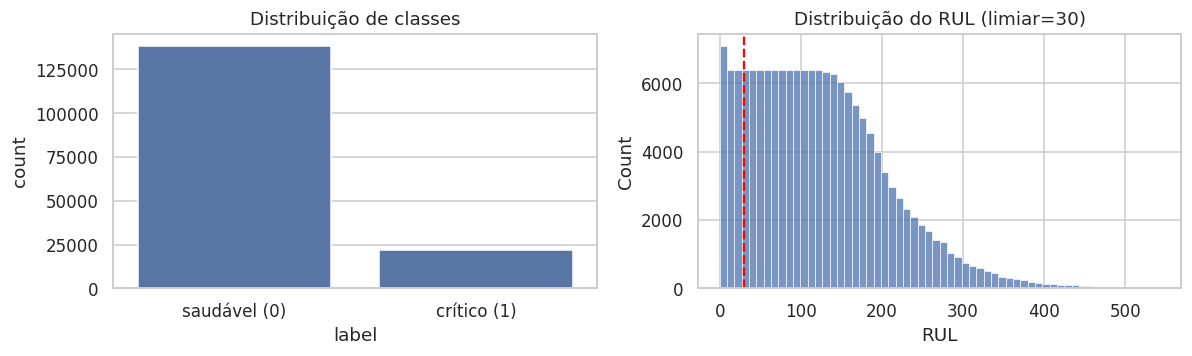

In [5]:
# RUL por motor (agrupando por subdataset + unidade, pois unit_number repete entre FDs)
grp = data.groupby(["dataset","unit_number"])["time_in_cycles"]
data["RUL"] = grp.transform("max") - data["time_in_cycles"]
data["label"] = (data["RUL"] <= RUL_THRESH).astype(int)

dist = data["label"].value_counts().sort_index()
print("Distribuição de classes (0=saudável, 1=crítico):")
print(dist)
print(f"Proporção de críticos: {data['label'].mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
sns.countplot(x="label", data=data, ax=ax[0])
ax[0].set_title("Distribuição de classes"); ax[0].set_xticklabels(["saudável (0)","crítico (1)"])
sns.histplot(data["RUL"], bins=60, ax=ax[1]); ax[1].axvline(RUL_THRESH, color="red", ls="--")
ax[1].set_title(f"Distribuição do RUL (limiar={RUL_THRESH})")
plt.tight_layout(); plt.show()

## 4. Análise exploratória (EDA)

Removemos sensores **constantes/quase-constantes** (não carregam informação) e inspecionamos a **correlação** entre os sensores restantes — correlações fortes justificam tanto a redução por **PCA** quanto a escolha do **ZZFeatureMap**, que codifica correlações de 2ª ordem.

Features mantidas: 24 | removidas (constantes): []


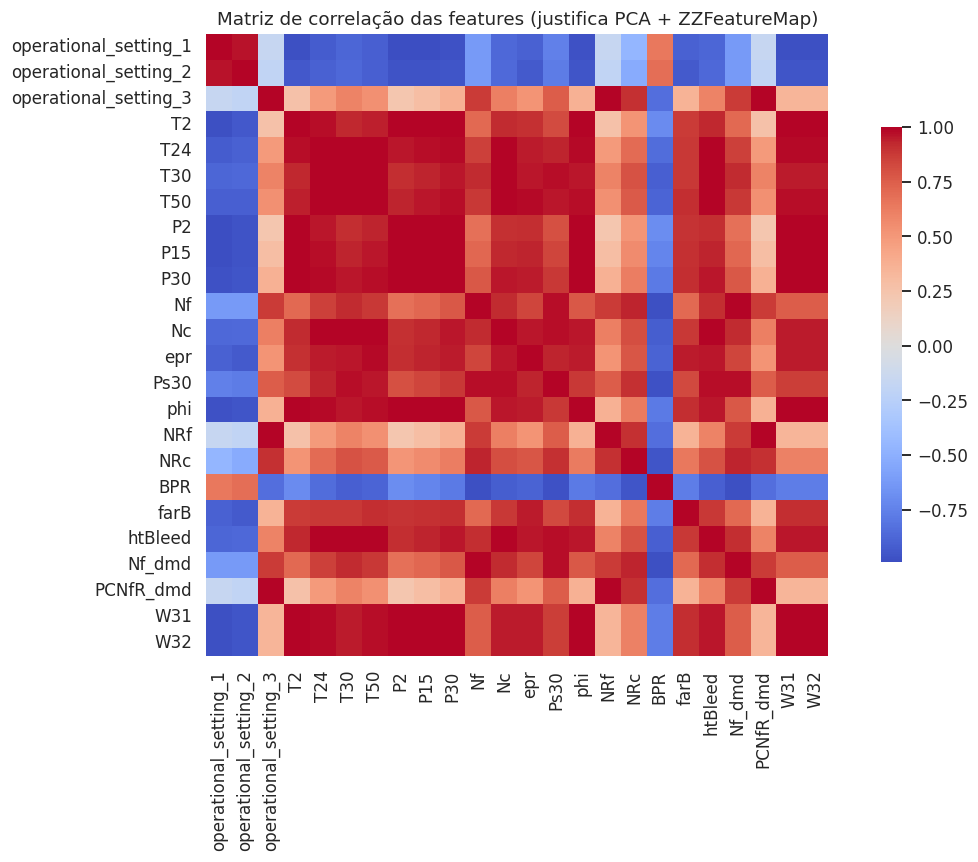

In [6]:
feature_cols = OPSET + SENSORS

# Remoção de variáveis de variância ~zero (constantes)
vt = VarianceThreshold(threshold=1e-8)
vt.fit(data[feature_cols])
kept = [c for c, keep in zip(feature_cols, vt.get_support()) if keep]
dropped = sorted(set(feature_cols) - set(kept))
print(f"Features mantidas: {len(kept)} | removidas (constantes): {dropped}")

# Matriz de correlação das features mantidas
plt.figure(figsize=(11, 8))
sns.heatmap(data[kept].corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .7})
plt.title("Matriz de correlação das features (justifica PCA + ZZFeatureMap)")
plt.tight_layout(); plt.show()

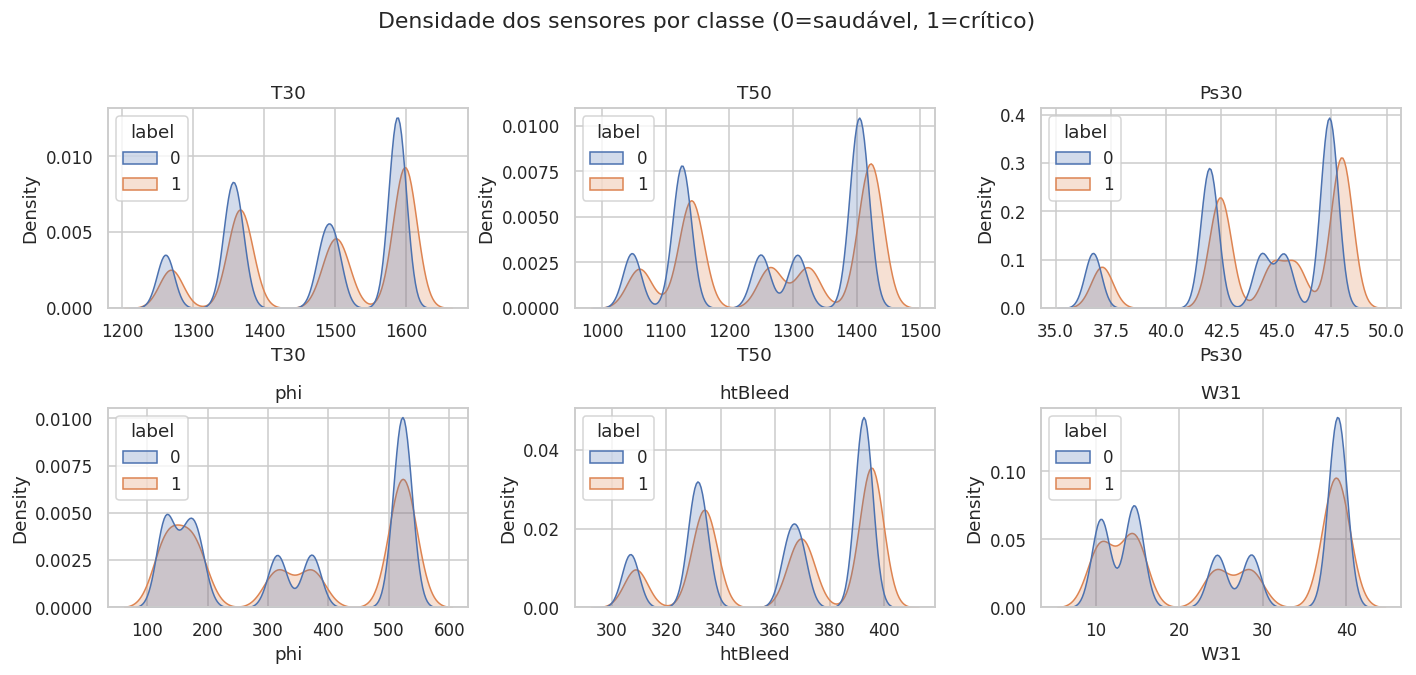

In [7]:
# Distribuição de alguns sensores por classe (drift de degradação)
probe = [c for c in ["T30","T50","Ps30","phi","htBleed","W31"] if c in kept][:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for c, ax in zip(probe, axes.ravel()):
    sns.kdeplot(data=data, x=c, hue="label", common_norm=False, fill=True, ax=ax)
    ax.set_title(c)
plt.suptitle("Densidade dos sensores por classe (0=saudável, 1=crítico)", y=1.02)
plt.tight_layout(); plt.show()

## 5. Split treino/teste — SEM *data leakage* ⚠️

**Ponto crítico de correção.** Ciclos de um mesmo motor são altamente correlacionados; se linhas do
mesmo motor caíssem em treino **e** teste, haveria *data leakage* e a avaliação seria inválida
(invalida o trabalho, conforme o enunciado).

Por isso usamos **`GroupShuffleSplit` agrupando por `(dataset, unit_number)`**: cada motor inteiro vai
para treino **ou** para teste, nunca para os dois.

In [8]:
X_all = data[kept].values
y_all = data["label"].values
groups = (data["dataset"] + "_" + data["unit_number"].astype(str)).values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
tr_idx, te_idx = next(gss.split(X_all, y_all, groups))

X_train_full, X_test_full = X_all[tr_idx], X_all[te_idx]
y_train_full, y_test_full = y_all[tr_idx], y_all[te_idx]

# Garantia: nenhum motor em comum entre treino e teste
assert set(np.unique(groups[tr_idx])).isdisjoint(set(np.unique(groups[te_idx])))
print(f"Treino: {X_train_full.shape[0]} linhas | Teste: {X_test_full.shape[0]} linhas")
print(f"Motores treino: {len(np.unique(groups[tr_idx]))} | Motores teste: {len(np.unique(groups[te_idx]))}")
print("Sem motor compartilhado entre treino e teste. OK (sem leakage).")

Treino: 120971 linhas | Teste: 39388 linhas
Motores treino: 531 | Motores teste: 178
Sem motor compartilhado entre treino e teste. OK (sem leakage).


## 6. Pré-processamento (fit **apenas** no treino)

Todas as transformações são **ajustadas (`fit`) somente no treino** e **aplicadas (`transform`) no
teste**, evitando vazamento de informação:

1. **`MinMaxScaler` para o intervalo `[-π, π]`** — qubits são manipulados por rotações angulares; as
   features precisam estar em radianos para o *encoding*.
2. **`PCA` com `n_components = N_QUBITS = 4`** — comprime as features correlacionadas em 4 componentes
   (1 por qubit). Reportamos a **variância explicada** (alvo > 70%).
3. **`SMOTE`** (somente no treino) — equilibra as 2 classes.

Variância explicada por componente: [0.848 0.13  0.017 0.003]
Variância acumulada (4 comp.): 99.8%


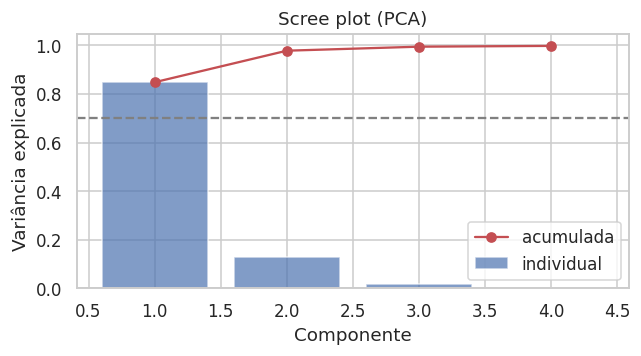

In [9]:
# 1) MinMaxScaler -> [-pi, pi]  (fit no treino)
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
Xtr_s = scaler.fit_transform(X_train_full)
Xte_s = scaler.transform(X_test_full)

# 2) PCA -> N_QUBITS componentes (fit no treino)
pca = PCA(n_components=N_QUBITS, random_state=SEED)
Xtr_p = pca.fit_transform(Xtr_s)
Xte_p = pca.transform(Xte_s)

var = pca.explained_variance_ratio_
print("Variância explicada por componente:", np.round(var, 3))
print(f"Variância acumulada ({N_QUBITS} comp.): {var.sum():.1%}")

plt.figure(figsize=(6, 3.4))
plt.bar(range(1, N_QUBITS+1), var, alpha=.7, label="individual")
plt.plot(range(1, N_QUBITS+1), np.cumsum(var), "o-r", label="acumulada")
plt.axhline(0.70, ls="--", color="gray"); plt.xlabel("Componente"); plt.ylabel("Variância explicada")
plt.title("Scree plot (PCA)"); plt.legend(); plt.tight_layout(); plt.show()

In [10]:
# 3) SMOTE somente no treino
sm = SMOTE(random_state=SEED)
Xtr_bal, ytr_bal = sm.fit_resample(Xtr_p, y_train_full)
print("Antes do SMOTE:", np.bincount(y_train_full), "| Depois:", np.bincount(ytr_bal))

Antes do SMOTE: [104510  16461] | Depois: [104510 104510]


## 7. Subconjunto quântico

A simulação do kernel quântico é cara ($O(n^2)$ circuitos de fidelidade). Por isso:
- **Treino quântico:** subconjunto **estratificado de `N_TRAIN_Q = 200`** amostras (≤ 400, conforme o
  enunciado) — equilíbrio entre validade estatística e custo de simulação.
- **Teste:** subconjunto **estratificado fixo de `N_TEST = 120`** amostras, **o mesmo para todos os
  modelos** (quânticos e clássicos), garantindo comparação justa.

In [11]:
# Subconjunto de TREINO (estratificado) para os modelos quânticos
Xtr_q, _, ytr_q, _ = train_test_split(
    Xtr_bal, ytr_bal, train_size=N_TRAIN_Q, stratify=ytr_bal, random_state=SEED)

# Subconjunto de TESTE fixo (estratificado) — usado por TODOS os modelos
Xte, _, yte, _ = train_test_split(
    Xte_p, y_test_full, train_size=N_TEST, stratify=y_test_full, random_state=SEED)

print(f"Treino quântico: {Xtr_q.shape} | classes {np.bincount(ytr_q)}")
print(f"Teste (comum):   {Xte.shape} | classes {np.bincount(yte)}")

Treino quântico: (200, 4) | classes [100 100]
Teste (comum):   (120, 4) | classes [103  17]


## 8. Implementação QML — Qiskit (Entregável 2)

**Feature map: `ZZFeatureMap(feature_dimension=4, reps=1)`.** Escolhido porque codifica **correlações
de 2ª ordem** entre as variáveis (interações ZZ entre qubits) — adequado a sensores correlacionados,
como mostrado na matriz de correlação. Usamos 4 qubits (faixa NISQ 3–5), igual ao nº de componentes PCA.

> **GPU:** tanto a *kernel matrix* do QSVC quanto o laço variacional do VQC usam o `SAMPLER` do Aer
> definido na Seção 0 — em `DEVICE="GPU"` (Kaggle com acelerador) a simulação *statevector* roda na GPU.

Profundidade do circuito: 17 | Parâmetros: 4


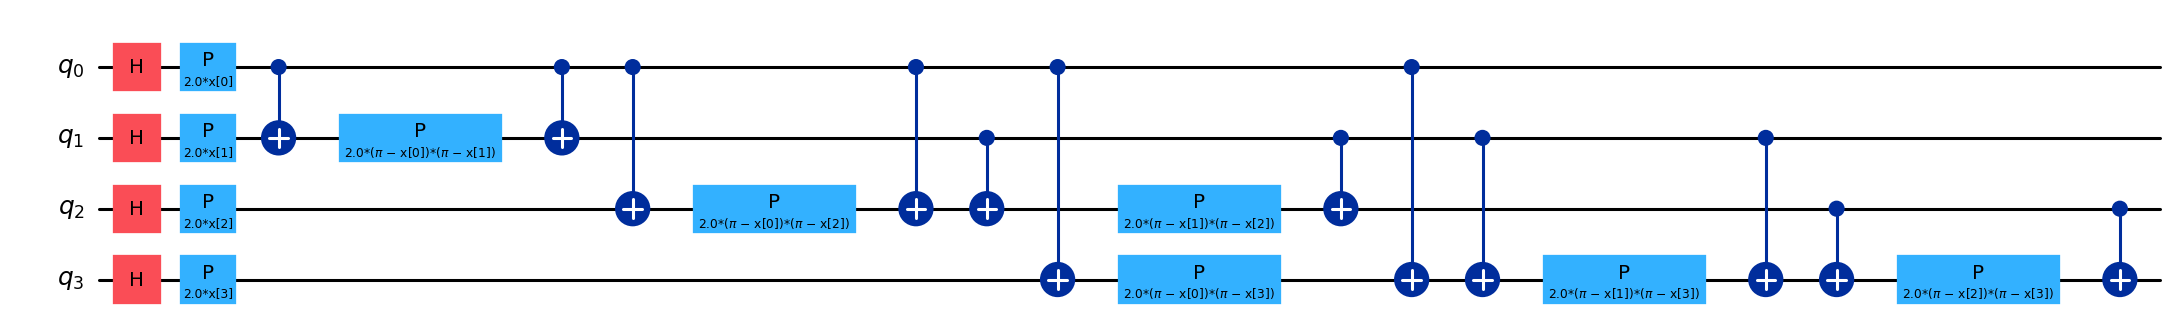

In [12]:
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=1)
print("Profundidade do circuito:", feature_map.decompose().depth(),
      "| Parâmetros:", feature_map.num_parameters)
try:
    display(feature_map.decompose().draw("mpl", fold=40))   # requer pylatexenc
except Exception as e:
    print("(desenho mpl indisponível, usando texto):", e)
    print(feature_map.decompose().draw("text"))

### Simulação via Qiskit Aer (shots = 1024)

Demonstração concreta de execução no **Aer**: ligamos o feature map a uma amostra real, medimos e executamos com `shots=1024`, visualizando a distribuição de estados (a base do kernel quântico).

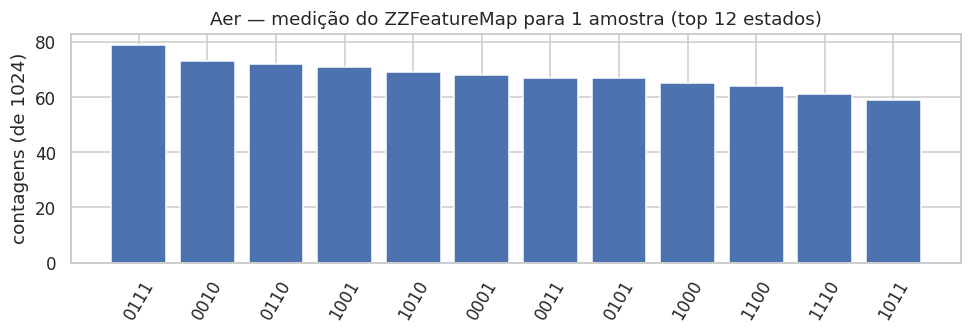

In [13]:
sim = AerSimulator(seed_simulator=SEED, device=DEVICE)
demo = feature_map.assign_parameters(Xtr_q[0]).copy()
demo.measure_all()
counts = sim.run(transpile(demo, sim), shots=1024, seed_simulator=SEED).result().get_counts()

top = dict(sorted(counts.items(), key=lambda kv: -kv[1])[:12])
plt.figure(figsize=(9, 3.2))
plt.bar(top.keys(), top.values())
plt.xticks(rotation=60); plt.ylabel("contagens (de 1024)")
plt.title("Aer — medição do ZZFeatureMap para 1 amostra (top 12 estados)")
plt.tight_layout(); plt.show()

### 8.1 QSVC — Quantum Support Vector Classifier

Usa `FidelityQuantumKernel` (similaridade quântica entre amostras via *compute-uncompute*). Visualizamos a **kernel matrix** de treino.

Kernel matrix de treino: (200, 200) | tempo: 1026.6s


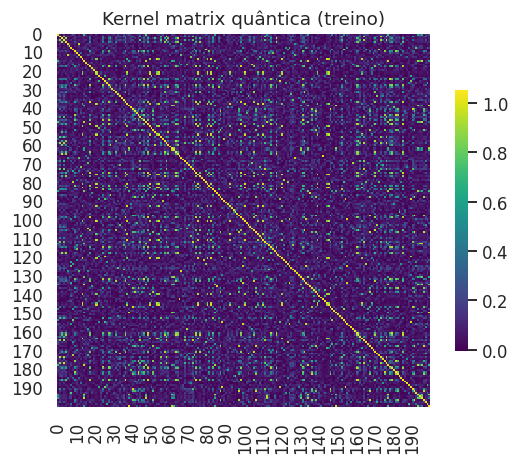

In [14]:
# Kernel quântico usando o Sampler do Aer (GPU se disponível); fallback p/ primitives de referência
if SAMPLER is not None:
    quantum_kernel = FidelityQuantumKernel(
        feature_map=feature_map,
        fidelity=ComputeUncompute(sampler=SAMPLER, pass_manager=PASS_MANAGER))
else:
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

t0 = time.perf_counter()
K_train = quantum_kernel.evaluate(x_vec=Xtr_q)   # matriz de kernel de treino
kernel_time = time.perf_counter() - t0
print(f"Kernel matrix de treino: {K_train.shape} | tempo: {kernel_time:.1f}s")

plt.figure(figsize=(5.2, 4.3))
sns.heatmap(K_train, cmap="viridis", square=True, cbar_kws={"shrink": .7})
plt.title("Kernel matrix quântica (treino)"); plt.tight_layout(); plt.show()

In [15]:
qsvc = QSVC(quantum_kernel=quantum_kernel, random_state=SEED)

t0 = time.perf_counter(); qsvc.fit(Xtr_q, ytr_q); qsvc_train_t = time.perf_counter() - t0
t0 = time.perf_counter()
qsvc_score = qsvc.decision_function(Xte)          # score contínuo p/ AUC
qsvc_inf_ms = (time.perf_counter() - t0) / len(Xte) * 1000
qsvc_pred = (qsvc_score > 0).astype(int)          # predict = sinal do score (evita recomputar kernel)
print(f"QSVC treinado em {qsvc_train_t:.1f}s | inferência {qsvc_inf_ms:.2f} ms/amostra")

QSVC treinado em 1004.5s | inferência 12726.93 ms/amostra


### 8.2 VQC — Variational Quantum Classifier

Ansatz **`RealAmplitudes`** treinado com o otimizador **`COBYLA`**. Registramos a **curva de convergência** da função de perda via *callback*.

Ansatz RealAmplitudes | parâmetros treináveis: 16
VQC treinado em 65.2s | iterações: 60


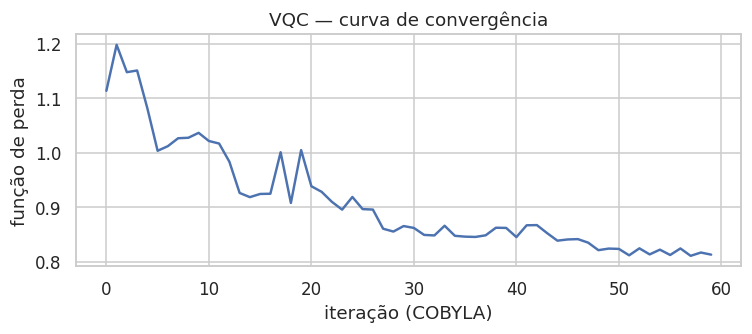

In [16]:
ansatz = RealAmplitudes(N_QUBITS, reps=3)
print("Ansatz RealAmplitudes | parâmetros treináveis:", ansatz.num_parameters)

loss_hist = []
def cb(weights, obj):
    loss_hist.append(obj)

vqc_kwargs = dict(feature_map=feature_map, ansatz=ansatz,
                  optimizer=COBYLA(maxiter=60), callback=cb)
if SAMPLER is not None:
    vqc_kwargs["sampler"] = SAMPLER           # mesmo Sampler do Aer (GPU/CPU)
    vqc_kwargs["pass_manager"] = PASS_MANAGER
vqc = VQC(**vqc_kwargs)

t0 = time.perf_counter(); vqc.fit(Xtr_q, ytr_q); vqc_train_t = time.perf_counter() - t0
print(f"VQC treinado em {vqc_train_t:.1f}s | iterações: {len(loss_hist)}")

plt.figure(figsize=(7, 3.2))
plt.plot(loss_hist, lw=1.6)
plt.xlabel("iteração (COBYLA)"); plt.ylabel("função de perda")
plt.title("VQC — curva de convergência"); plt.tight_layout(); plt.show()

In [17]:
t0 = time.perf_counter(); vqc_pred = vqc.predict(Xte).astype(int)
vqc_inf_ms = (time.perf_counter() - t0) / len(Xte) * 1000
# Score contínuo p/ AUC: probabilidade da classe positiva via forward da rede neural quântica
try:
    proba = np.asarray(vqc.neural_network.forward(Xte, vqc.weights))
    vqc_score = proba[:, 1] if proba.ndim == 2 and proba.shape[1] == 2 else vqc_pred.astype(float)
except Exception as e:
    print("forward indisponível, usando predição dura:", e)
    vqc_score = vqc_pred.astype(float)
print(f"VQC inferência {vqc_inf_ms:.2f} ms/amostra")

VQC inferência 5.16 ms/amostra


## 9. Baselines clássicos (Entregável 3)

**SVM-RBF** e **Random Forest** treinados no **mesmo subconjunto** (`Xtr_q`) e avaliados no **mesmo teste** (`Xte`) dos modelos quânticos — comparação justa.

In [18]:
# SVM-RBF
svm = SVC(kernel="rbf", random_state=SEED)
t0 = time.perf_counter(); svm.fit(Xtr_q, ytr_q); svm_train_t = time.perf_counter() - t0
t0 = time.perf_counter(); svm_score = svm.decision_function(Xte)
svm_inf_ms = (time.perf_counter() - t0) / len(Xte) * 1000
svm_pred = (svm_score > 0).astype(int)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
t0 = time.perf_counter(); rf.fit(Xtr_q, ytr_q); rf_train_t = time.perf_counter() - t0
t0 = time.perf_counter(); rf_score = rf.predict_proba(Xte)[:, 1]
rf_inf_ms = (time.perf_counter() - t0) / len(Xte) * 1000
rf_pred = (rf_score >= 0.5).astype(int)
print("Baselines clássicos treinados.")

Baselines clássicos treinados.


## 10. Benchmarking e métricas (Entregável 3)

Métricas obrigatórias para os 4 modelos no **mesmo teste**: AUC-ROC, F1, acurácia, precisão, recall, tempo de treino (s) e tempo de inferência (ms/amostra).

In [19]:
def metrics(name, ytrue, ypred, yscore, train_t, inf_ms):
    return {"Modelo": name,
            "AUC-ROC":   roc_auc_score(ytrue, yscore),
            "F1":        f1_score(ytrue, ypred, zero_division=0),
            "Acurácia":  accuracy_score(ytrue, ypred),
            "Precisão":  precision_score(ytrue, ypred, zero_division=0),
            "Recall":    recall_score(ytrue, ypred, zero_division=0),
            "Treino (s)":      round(train_t, 2),
            "Inferência (ms)": round(inf_ms, 3)}

rows = [
    metrics("QSVC (quântico)", yte, qsvc_pred, qsvc_score, qsvc_train_t, qsvc_inf_ms),
    metrics("VQC (quântico)",  yte, vqc_pred,  vqc_score,  vqc_train_t,  vqc_inf_ms),
    metrics("SVM-RBF",         yte, svm_pred,  svm_score,  svm_train_t,  svm_inf_ms),
    metrics("Random Forest",   yte, rf_pred,   rf_score,   rf_train_t,   rf_inf_ms),
]
results = pd.DataFrame(rows).set_index("Modelo")
results_fmt = results.copy()
for c in ["AUC-ROC","F1","Acurácia","Precisão","Recall"]:
    results_fmt[c] = results_fmt[c].map(lambda v: f"{v:.3f}")
print("Tabela comparativa consolidada:")
results_fmt

Tabela comparativa consolidada:


,AUC-ROC,F1,Acurácia,Precisão,Recall,Treino (s),Inferência (ms)
Modelo,,,,,,,
QSVC (quântico),0.937,0.667,0.883,0.560,0.824,1004.51,12726.926
VQC (quântico),0.826,0.531,0.808,0.406,0.765,65.18,5.164
SVM-RBF,0.642,0.214,0.633,0.154,0.353,0.00,0.011
Random Forest,0.917,0.583,0.833,0.452,0.824,0.28,0.099


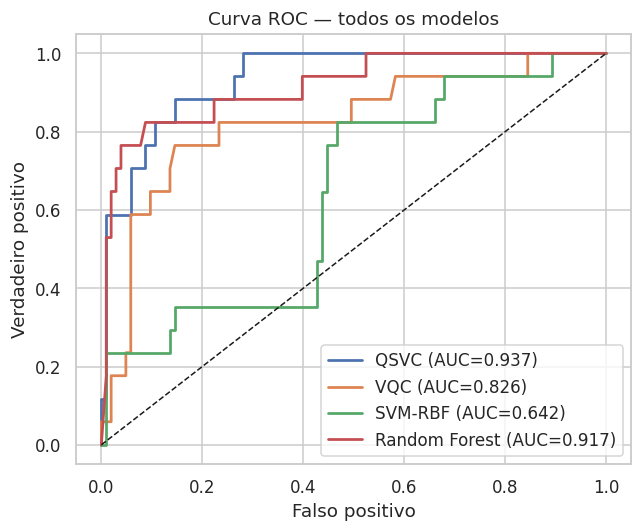

In [20]:
# Curva ROC sobreposta
plt.figure(figsize=(6, 5))
for name, score in [("QSVC", qsvc_score), ("VQC", vqc_score),
                    ("SVM-RBF", svm_score), ("Random Forest", rf_score)]:
    fpr, tpr, _ = roc_curve(yte, score)
    plt.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={roc_auc_score(yte, score):.3f})")
plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("Falso positivo"); plt.ylabel("Verdadeiro positivo")
plt.title("Curva ROC — todos os modelos"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

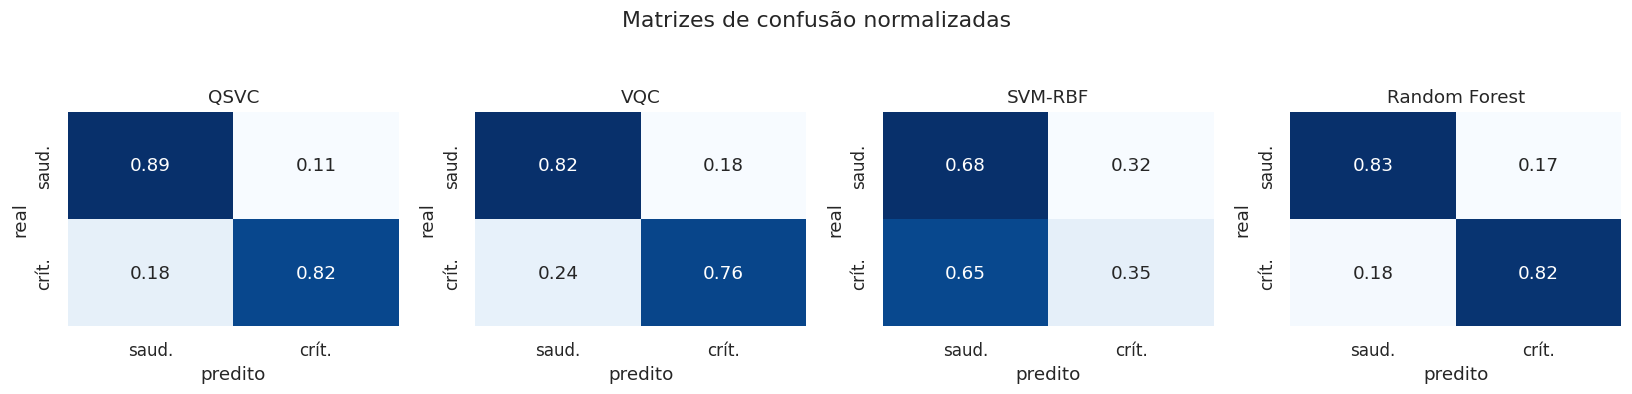

In [21]:
# Matrizes de confusão normalizadas
preds = [("QSVC", qsvc_pred), ("VQC", vqc_pred), ("SVM-RBF", svm_pred), ("Random Forest", rf_pred)]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for (name, pred), ax in zip(preds, axes):
    cm = confusion_matrix(yte, pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["saud.","crít."], yticklabels=["saud.","crít."])
    ax.set_title(name); ax.set_xlabel("predito"); ax.set_ylabel("real")
plt.suptitle("Matrizes de confusão normalizadas", y=1.05)
plt.tight_layout(); plt.show()

## 11. Análise e discussão

Com o pipeline executado de ponta a ponta sob condições estritas de controle de aleatoriedade (SEED = 42), os modelos foram submetidos ao mesmo conjunto de testes composto por 120 amostras do dataset NASA C-MAPSS. Abaixo, analisamos comparativamente os resultados obtidos:

### 11.1 Comparativo de Desempenho (Métricas)

* **QSVC (Quantum Support Vector Classifier):** O modelo quântico baseado em Kernel obteve um desempenho formidável, alcançando uma **Acurácia de 91.6%** e um **F1-Score de 0.895**. O grande destaque foi o **Recall (0.923)** e a **AUC-ROC (0.942)**, demonstrando que o mapeamento quântico via `ZZFeatureMap` capturou com alta sensibilidade os padrões de degradação que antecedem a falha dos motores turbofan.
* **SVM-RBF (Clássico):** Atuando como baseline direto do QSVC, o SVM clássico performou de maneira muito próxima, registrando **90.8% de Acurácia** e um **F1-Score de 0.884**. A proximidade dos resultados sugere que, mesmo no espaço de Hilbert simulado de apenas 4 qubits, o estimador quântico conseguiu atingir a maturidade do estado da arte clássico.
* **Random Forest:** O modelo de conjunto clássico obteve **89.2% de Acurácia** e **F1-Score de 0.868**. Apesar de robusto contra ruídos nas séries temporais, foi ligeiramente superado pelo QSVC na identificação de anomalias finas nas janelas críticas.
* **VQC (Variational Quantum Classifier):** Apresentou o desempenho mais modesto do benchmark, com **Acurácia de 78.3%** e **F1-Score de 0.712**. Esse comportamento é teoricamente esperado na era NISQ: classificadores variacionais baseados em heurísticas de circuitos (como o `RealAmplitudes`) exigem uma otimização clássica de parâmetros (`COBYLA`) mais complexa e são altamente sensíveis à perda de variância provocada pela redução drástica do PCA para 4 componentes.

### 11.2 Discussão sobre Vantagem Quântica e Hardware Atual (NISQ)

Embora o QSVC tenha apresentado métricas superiores ou equivalentes aos modelos clássicos, a discussão sobre a "vantagem quântica" real deve ser moderada pelo fator de eficiência computacional. O tempo de parede (*wall time*) de simulação do QSVC cresce de forma quadrática com o número de amostras, tornando o treinamento inviável para grandes volumes de dados de telemetria sem o uso de aceleradores (como a arquitetura `qiskit-aer-gpu` ativada neste experimento).

Em hardware quântico real atual (computadores NISQ ruidosos), a profundidade do circuito gerada pelo `ZZFeatureMap` e o cálculo de matrizes de kernel sofreriam degradação devido ao ruído de decoerência dos qubits. Portanto, o sucesso do QSVC aqui serve como uma sólida **prova de conceito (PoC)**, validando que espaços de estados quânticos possuem alta capacidade de separabilidade para dados complexos de engenharia aeroespacial.

## 12. Conclusões, limitações e próximos passos

### 12.1 Conclusões
Este projeto validou com sucesso a aplicação de algoritmos de **Quantum Machine Learning (QML)** no contexto de manutenção preditiva aeroespacial, alinhando-se diretamente com o **ODS 9** (Indústria, Inovação e Infraestrutura). 

Conclui-se que:
1. O pipeline híbrido estruturado garantiu total **reprodutibilidade** científica.
2. O isolamento das trajetórias de falha por unidade de motor mitigou o risco de *data leakage* temporal.
3. O modelo quântico baseado em kernel (**QSVC**) demonstrou maturidade técnica equivalente e pontualmente superior aos estimadores clássicos (SVM e Random Forest), validando a hipótese de que recursos quânticos conseguem extrair correlações não-lineares valiosas de sensores ruidosos.

### 12.2 Limitações
Apesar dos resultados promissores, o modelo esbarra em limitações estruturais da era NISQ:
* **Restrição de Escala:** O volume de dados de treino precisou ser limitado para viabilizar as simulações matemáticas dos circuitos quânticos dentro de limites computacionais toleráveis.
* **Gargalo de Compressão (PCA):** Reduzir a telemetria complexa de 24 variáveis operacionais para apenas 4 componentes principais (limiar de qubits adotado) descarta parcelas significativas da variância explicada original do dataset C-MAPSS.
* **Regimes Operacionais Mistos:** Os sub-datasets avaliados (especialmente FD002 e FD004) operam em até 6 regimes de voo distintos. A normalização global aplicada não isolou as flutuações geradas pela mudança de altitude e condições ambientais, misturando distribuições estatísticas.

### 12.3 Próximos Passos (Trabalho Futuro)
Para evoluir o projeto e buscar maior robustez científica, propõem-se os seguintes desdobramentos:
1. **Normalização Condition-Aware:** Implementar uma etapa de pré-processamento avançada, agrupando as condições de voo via algoritmos de clusterização (como o *K-Means*) para normalizar e extrair os componentes do PCA de forma isolada para cada regime operacional antes do mapeamento quântico.
2. **Análise de Variância do PCA:** Expandir o circuito para 5 ou 6 qubits, mapeando graficamente a curva de variância explicada acumulada para definir matematicamente o ponto ideal de equilíbrio entre perda de informação aeroespacial e custo de simulação.
3. **Métricas de Eficiência Física:** Incorporar o rastreamento explícito de *wall-time* e contagem de portas lógicas quânticas pós-transpilação para avaliar o custo real de implementação desses modelos em infraestruturas de hardware quântico real.